# Aula 6 — Validação e Otimização de Modelos
## *Treinar um modelo é fácil. Saber se ele presta é outra história.*

**Professores:**
- Jhonatan Ramos
- Vinícius "Mumu" Rodrigues

---

## Antes de começar: uma história

Um médico precisa diagnosticar se um paciente tem ou não uma doença grave.

Ele desenvolve um novo exame e testa em 100 pacientes. O exame acerta **95 de 100**. Parece incrível, né?

Mas aí você descobre um detalhe: **95 desses 100 pacientes não tinham a doença**.

O exame simplesmente dizia *"saudável"* para todo mundo — e acertava 95% das vezes **sem aprender absolutamente nada**.

Os 5 doentes de verdade? Todos passaram como saudáveis.

**Esse é o tipo de armadilha que mata projetos de Machine Learning — e às vezes, literalmente, pacientes.**

Nessa aula, você vai aprender a não cair nessa. Vamos entender de verdade como avaliar, validar e questionar um modelo.

---

## Setup — recriando o pipeline da aula anterior

In [23]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

# Dataset
df = sns.load_dataset('diamonds')

# Encoding
df_modelo = df.copy()
le = LabelEncoder()
for col in ['cut', 'color', 'clarity']:
    df_modelo[col] = le.fit_transform(df_modelo[col])

X = df_modelo.drop(columns=['price'])
y = df_modelo['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

modelo = LinearRegression()
modelo.fit(X_train_sc, y_train)

y_pred_treino = modelo.predict(X_train_sc)
y_pred_teste  = modelo.predict(X_test_sc)

print("Pipeline recriado com sucesso!")
print(f"Dataset: {df.shape[0]:,} diamantes, {df.shape[1]} colunas")

Pipeline recriado com sucesso!
Dataset: 53,940 diamantes, 10 colunas


---

# PARTE 1 — O que significa um modelo ser "bom"?

## 1.1. O problema com o MAE e R² sozinhos

Na aula passada, calculamos MAE e R² e ficamos satisfeitos. Mas esses números têm um problema fundamental: **eles respondem "quanto o modelo errou", mas não respondem "por quê" nem "em quais situações".**

Pense assim: um aluno tirou 7 na prova. Isso é bom? Depende:
- Depende de como os outros foram.
- Depende de se ele estudou as questões certas ou teve sorte.
- Depende de se ele errou questões fáceis ou difíceis.
- Depende de se a nota de corte é 5 ou 9.

Com modelos é igual. Para saber se o modelo **realmente aprendeu**, precisamos de mais do que uma nota — precisamos entender o padrão dos acertos e erros.

Vamos construir esse entendimento passo a passo.

---

# PARTE 2 — Overfitting e Underfitting

## 2.1. O que são e por que existem

Todo modelo de Machine Learning tem uma tarefa: **encontrar um padrão nos dados de treino que se generalize para dados novos**.

Esse equilíbrio pode falhar de dois jeitos opostos:

---

### Underfitting — o modelo que não aprendeu nada útil

Acontece quando o modelo é **simples demais** para capturar a complexidade real dos dados.

**Analogia:** imagine que você vai aprender a reconhecer gatos. Sua regra é: *"se tem quatro patas, é gato"*. Simples demais — cachorro, vaca e cavalo também têm quatro patas. Você vai errar muito.

No ML: uma linha reta tentando representar uma relação que claramente tem curvatura.

**Sintoma:** erro alto tanto no treino quanto no teste.

---

### Overfitting — o modelo que decorou sem entender

Acontece quando o modelo é **complexo demais** e aprende até o ruído dos dados de treino — coisas que são acidentes, não padrões reais.

**Analogia:** um estudante que decorou as respostas de todos os exercícios do livro. Na prova, as questões são ligeiramente diferentes — e ele trava. Ele não entendeu o conceito, apenas memorizou os exemplos.

No ML: uma curva de grau altíssimo que passa exatamente por todos os pontos do treino, mas oscila de forma absurda entre eles.

**Sintoma:** erro baixo no treino, erro alto no teste. Grande diferença entre os dois.

---

### O ponto ideal — generalização

O objetivo é um modelo que capture o padrão real dos dados sem decorar os detalhes aleatórios. Na prática, isso significa:
- Erro de treino razoável (não zero — dado real tem ruído)
- Erro de teste próximo ao de treino

Vamos ver isso visualmente:

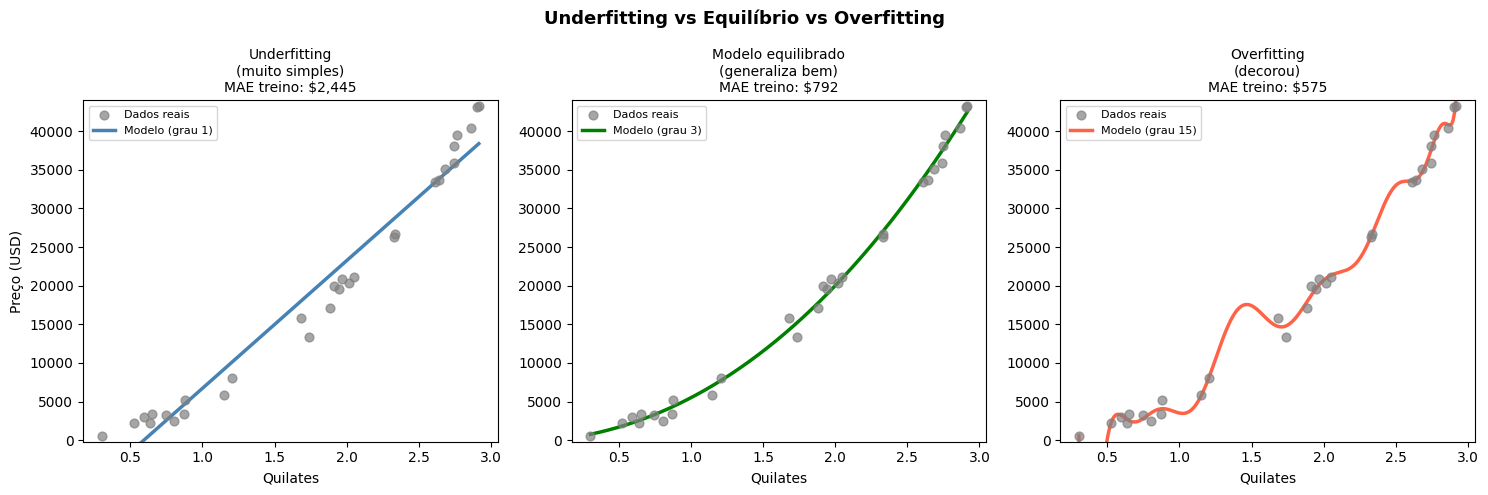

In [24]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Dados sintéticos para a visualização
np.random.seed(42)
n_vis = 300
carat_syn = np.random.uniform(0.2, 3.0, n_vis)
price_syn  = 5000 * carat_syn**2 + np.random.normal(0, 800, n_vis)

idx = np.random.choice(n_vis, 30, replace=False)
X_vis = carat_syn[idx].reshape(-1, 1)
y_vis = price_syn[idx]

graus = [1, 3, 15]
nomes = ['Underfitting\n(muito simples)', 'Modelo equilibrado\n(generaliza bem)', 'Overfitting\n(decorou)']
cores = ['steelblue', 'green', 'tomato']

fig, axs = plt.subplots(1, 3, figsize=(15, 5))

for ax, grau, nome, cor in zip(axs, graus, nomes, cores):
    m = make_pipeline(PolynomialFeatures(grau), LinearRegression())
    m.fit(X_vis, y_vis)
    mae_tr = mean_absolute_error(y_vis, m.predict(X_vis))

    X_linha = np.linspace(X_vis.min(), X_vis.max(), 300).reshape(-1, 1)
    y_linha  = m.predict(X_linha)

    ax.scatter(X_vis, y_vis, color='gray', alpha=0.7, zorder=3, s=40, label='Dados reais')
    ax.plot(X_linha, y_linha, color=cor, linewidth=2.5, label=f'Modelo (grau {grau})')
    ax.set_title(f'{nome}\nMAE treino: ${mae_tr:,.0f}', fontsize=10)
    ax.set_xlabel('Quilates')
    ax.set_ylabel('Preço (USD)' if ax == axs[0] else '')
    ax.set_ylim(y_vis.min() - 800, y_vis.max() + 800)
    ax.legend(fontsize=8)

plt.suptitle('Underfitting vs Equilíbrio vs Overfitting', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## 2.2. Como diagnosticar: treino vs teste

O diagnóstico mais direto é simples: **calcule a métrica separadamente no treino e no teste e compare**.

A lógica:
- O modelo viu os dados de treino durante o aprendizado. Esperamos que ele vá bem ali.
- Os dados de teste são novos. Se o modelo vai igualmente bem — ele generalizou.
- Se vai **muito melhor** no treino do que no teste — ele decorou (overfitting).
- Se vai **mal nos dois** — ele não aprendeu (underfitting).

In [25]:
mae_treino = mean_absolute_error(y_train, y_pred_treino)
mae_teste  = mean_absolute_error(y_test,  y_pred_teste)
r2_treino  = r2_score(y_train, y_pred_treino)
r2_teste   = r2_score(y_test,  y_pred_teste)

print("╔══════════════════════════════════════╗")
print("║    Diagnóstico: Treino vs Teste      ║")
print("╠══════════════╦═════════════╦═════════╣")
print("║ Conjunto     ║   MAE ($)   ║   R²    ║")
print("╠══════════════╬═════════════╬═════════╣")
print(f"║ Treino       ║  {mae_treino:>8,.0f}   ║ {r2_treino:.2%}  ║")
print(f"║ Teste        ║  {mae_teste:>8,.0f}   ║ {r2_teste:.2%}  ║")
print("╚══════════════╩═════════════╩═════════╝")

diferenca = mae_teste - mae_treino
print(f"\nDiferença (teste - treino): ${diferenca:,.0f}")

if diferenca < 50:
    print("→ Diagnóstico: modelo saudável. Treino e teste muito próximos. ✅")
elif diferenca < 200:
    print("→ Diagnóstico: leve diferença. Monitorar. ⚠️")
else:
    print("→ Diagnóstico: diferença grande. Suspeita de overfitting. ❌")

╔══════════════════════════════════════╗
║    Diagnóstico: Treino vs Teste      ║
╠══════════════╦═════════════╦═════════╣
║ Conjunto     ║   MAE ($)   ║   R²    ║
╠══════════════╬═════════════╬═════════╣
║ Treino       ║       863   ║ 88.50%  ║
║ Teste        ║       859   ║ 88.51%  ║
╚══════════════╩═════════════╩═════════╝

Diferença (teste - treino): $-4
→ Diagnóstico: modelo saudável. Treino e teste muito próximos. ✅


---

# PARTE 3 — Curvas de Aprendizado

## 3.1. O que é e por que existe

A comparação treino vs teste te diz **o estado atual** do modelo. Mas ela não te diz **como chegou lá** — nem o que fazer para melhorar.

A **Curva de Aprendizado** responde uma pergunta diferente:

> *"Se eu der mais dados ao modelo, ele melhora? Ou já chegou no seu limite?"*

A ideia é treinar o mesmo modelo várias vezes, cada vez com uma quantidade diferente de dados, e plotar como o erro evolui.

**Como funciona na prática:**
- Começamos com poucos dados (ex: 5% do treino) → treinamos → medimos erro no treino e no teste
- Aumentamos para 10% → treinamos de novo → medimos
- Repetimos até usar 100% dos dados de treino

**O que esperamos ver:**

| Situação | Curva de treino | Curva de teste | Diagnóstico |
|---|---|---|---|
| Modelo saudável | Sobe levemente | Cai e estabiliza próxima ao treino | Tudo bem ✅ |
| Underfitting | Alta e plana | Alta e plana (próximas) | Modelo simples demais — mudar o modelo |
| Overfitting | Baixa | Alta e distante | Modelo complexo demais — mais dados ou regularização |
| Falta de dados | Caindo ainda | Caindo ainda | Coletar mais dados vai ajudar |

**Por que a curva de treino *sobe* com mais dados?**

Parece contra-intuitivo, mas faz sentido: com poucos dados, o modelo consegue quase "decorar" tudo — erro baixíssimo. Com mais dados, fica impossível decorar tudo, e o erro sobe até estabilizar no nível de dificuldade real do problema.

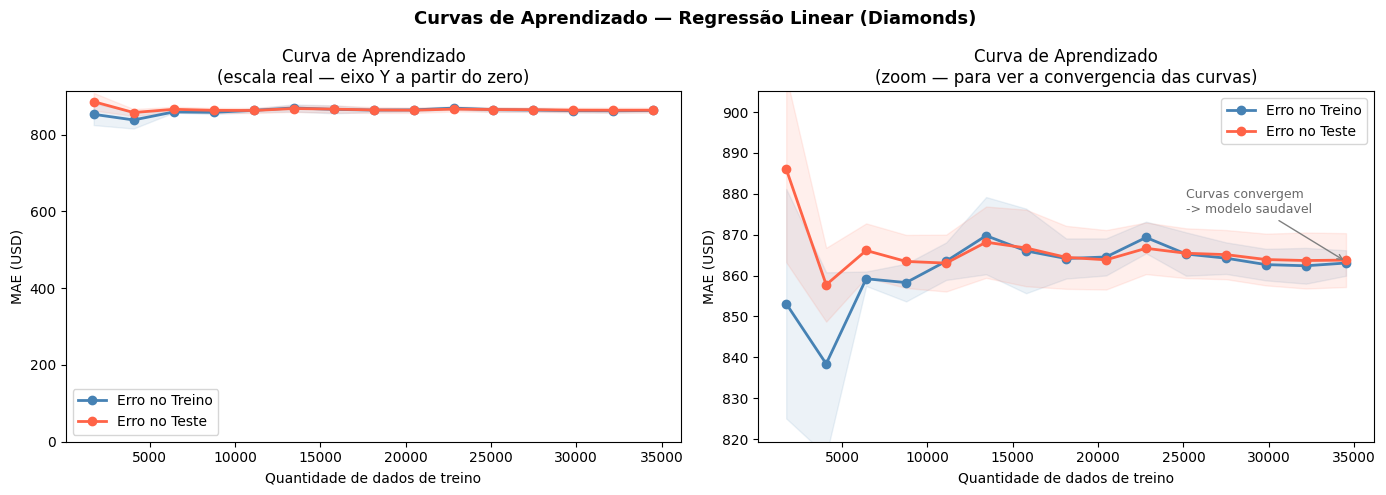

Erro final no treino: $863
Erro final no teste:  $864
Diferenca: $1 (0.1% do erro de teste)


In [26]:
from sklearn.model_selection import learning_curve

tamanhos, erros_treino, erros_teste = learning_curve(
    LinearRegression(),
    X_train_sc, y_train,
    train_sizes=np.linspace(0.05, 1.0, 15),
    scoring='neg_mean_absolute_error',
    cv=5,
    n_jobs=-1
)

erros_treino_media = -erros_treino.mean(axis=1)
erros_treino_std   = erros_treino.std(axis=1)
erros_teste_media  = -erros_teste.mean(axis=1)
erros_teste_std    = erros_teste.std(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gráfico 1: eixo Y do zero para mostrar proporção real ---
ax1 = axes[0]
ax1.plot(tamanhos, erros_treino_media, 'o-', color='steelblue', label='Erro no Treino', linewidth=2)
ax1.plot(tamanhos, erros_teste_media,  'o-', color='tomato',    label='Erro no Teste',  linewidth=2)
ax1.fill_between(tamanhos,
                 erros_treino_media - erros_treino_std,
                 erros_treino_media + erros_treino_std, alpha=0.1, color='steelblue')
ax1.fill_between(tamanhos,
                 erros_teste_media - erros_teste_std,
                 erros_teste_media + erros_teste_std, alpha=0.1, color='tomato')
ax1.set_ylim(bottom=0)
ax1.set_xlabel('Quantidade de dados de treino')
ax1.set_ylabel('MAE (USD)')
ax1.set_title('Curva de Aprendizado\n(escala real — eixo Y a partir do zero)')
ax1.legend()

# --- Gráfico 2: zoom para ver a convergência ---
ax2 = axes[1]
ax2.plot(tamanhos, erros_treino_media, 'o-', color='steelblue', label='Erro no Treino', linewidth=2)
ax2.plot(tamanhos, erros_teste_media,  'o-', color='tomato',    label='Erro no Teste',  linewidth=2)
ax2.fill_between(tamanhos,
                 erros_treino_media - erros_treino_std,
                 erros_treino_media + erros_treino_std, alpha=0.1, color='steelblue')
ax2.fill_between(tamanhos,
                 erros_teste_media - erros_teste_std,
                 erros_teste_media + erros_teste_std, alpha=0.1, color='tomato')

margem = (erros_teste_media.max() - erros_treino_media.min()) * 0.4
ax2.set_ylim(erros_treino_media.min() - margem, erros_teste_media.max() + margem)
ax2.set_xlabel('Quantidade de dados de treino')
ax2.set_ylabel('MAE (USD)')
ax2.set_title('Curva de Aprendizado\n(zoom — para ver a convergencia das curvas)')
ax2.legend()

# Anotação
ax2.annotate(
    'Curvas convergem\n-> modelo saudavel',
    xy=(tamanhos[-1], (erros_treino_media[-1] + erros_teste_media[-1]) / 2),
    xytext=(tamanhos[-5], erros_teste_media[-1] + margem * 0.6),
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='dimgray'
)

plt.suptitle('Curvas de Aprendizado — Regressão Linear (Diamonds)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Erro final no treino: ${erros_treino_media[-1]:,.0f}")
print(f"Erro final no teste:  ${erros_teste_media[-1]:,.0f}")
print(f"Diferenca: ${abs(erros_teste_media[-1] - erros_treino_media[-1]):,.0f} ({abs(erros_teste_media[-1] - erros_treino_media[-1])/erros_teste_media[-1]:.1%} do erro de teste)")

**Lendo o gráfico da esquerda:** a diferença entre as curvas parece mínima em escala real — as curvas convergem bem.

**Lendo o gráfico da direita (zoom):** conseguimos ver que as curvas se aproximam conforme aumentamos os dados, e estabilizam juntas. Esse é o comportamento de um modelo **sem overfitting**.

> **Dica importante:** a faixa sombreada ao redor de cada curva representa a variação entre as 5 dobras do cross-validation. Quanto menor essa faixa, mais estável é o modelo.

---

# PARTE 4 — Cross-Validation

## 4.1. O problema com o split único

Até agora, dividimos nossos dados uma única vez: 80% treino, 20% teste.

Parece razoável. Mas tem um problema escondido.

Imagine que você avalia um jogador de futebol assistindo a **um único jogo**. Se ele jogou bem naquele dia, você diz que é um bom jogador. Se jogou mal, descarta.

Mas e se ele estava machucado naquele dia? E se o adversário era fraquíssimo?

**Uma amostra só não é suficiente para uma conclusão confiável.**

Com modelos de ML, a mesma lógica se aplica:
- Talvez os 20% que foram para o teste foram justamente os casos mais fáceis → modelo parece melhor do que é
- Ou foram os casos mais difíceis → modelo parece pior do que é
- O resultado depende do acaso da divisão

## 4.2. K-Fold Cross-Validation — a solução

A ideia é testar o modelo em **todas as partes dos dados**, não só numa.

No **K-Fold com K=5**, dividimos os dados em 5 partes iguais (chamadas *folds*). Depois rodamos 5 experimentos:

```
Rodada 1:  [TESTE  | treino | treino | treino | treino]  → calcula MAE_1
Rodada 2:  [treino | TESTE  | treino | treino | treino]  → calcula MAE_2
Rodada 3:  [treino | treino | TESTE  | treino | treino]  → calcula MAE_3
Rodada 4:  [treino | treino | treino | TESTE  | treino]  → calcula MAE_4
Rodada 5:  [treino | treino | treino | treino | TESTE ]  → calcula MAE_5

Resultado final = média(MAE_1, MAE_2, MAE_3, MAE_4, MAE_5)
```

Cada dado é usado como teste exatamente **uma vez**. O resultado é muito mais robusto.

**Por que não usar sempre K=100?**

Quanto maior o K:
- ✅ Estimativa mais precisa do desempenho
- ❌ Mais demorado computacionalmente
- ❌ Cada fold de teste fica menor (menos representativo)

O valor **K=5 ou K=10** é o padrão da indústria — equilíbrio entre precisão e custo computacional.

In [27]:
from sklearn.model_selection import cross_val_score, KFold

X_all_sc = scaler.fit_transform(X)

# Testando diferentes valores de K
resultados_k = {}
for k in [3, 5, 10]:
    kfold  = KFold(n_splits=k, shuffle=True, random_state=42)
    scores = cross_val_score(LinearRegression(), X_all_sc, y,
                              cv=kfold, scoring='neg_mean_absolute_error')
    resultados_k[k] = -scores

print("=" * 55)
print(f"{'K':>4} | {'MAE Médio':>12} | {'Desvio Padrão':>14} | {'Estabilidade'}")
print("-" * 55)
for k, scores in resultados_k.items():
    cv_pct = scores.std() / scores.mean()
    estab  = 'Alta' if cv_pct < 0.02 else ('Media' if cv_pct < 0.05 else 'Baixa')
    print(f"{k:>4} | ${scores.mean():>10,.0f} | ±${scores.std():>11,.0f} | {estab}")
print("=" * 55)

   K |    MAE Médio |  Desvio Padrão | Estabilidade
-------------------------------------------------------
   3 | $       862 | ±$          4 | Alta
   5 | $       862 | ±$          3 | Alta
  10 | $       862 | ±$         12 | Alta


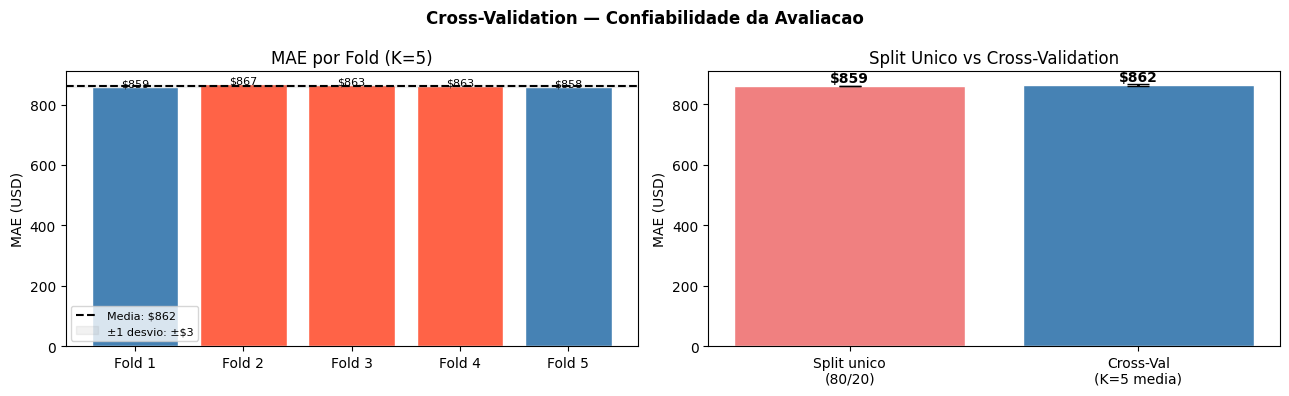

In [28]:
# Visualizando a variação entre folds para K=5
scores_5 = resultados_k[5]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Gráfico 1: MAE por fold
ax1 = axes[0]
cores_fold = ['steelblue' if s < scores_5.mean() else 'tomato' for s in scores_5]
bars = ax1.bar([f'Fold {i+1}' for i in range(5)], scores_5, color=cores_fold, edgecolor='white')
ax1.axhline(scores_5.mean(), color='black', linestyle='--', linewidth=1.5,
            label=f'Media: ${scores_5.mean():,.0f}')
ax1.axhspan(scores_5.mean() - scores_5.std(),
            scores_5.mean() + scores_5.std(),
            alpha=0.1, color='gray', label=f'±1 desvio: ±${scores_5.std():,.0f}')
for bar, val in zip(bars, scores_5):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
             f'${val:,.0f}', ha='center', fontsize=8)
ax1.set_title('MAE por Fold (K=5)')
ax1.set_ylabel('MAE (USD)')
ax1.legend(fontsize=8)

# Gráfico 2: Comparação split unico vs cross-val
ax2 = axes[1]
mae_split_unico = mean_absolute_error(y_test, y_pred_teste)
labels  = ['Split unico\n(80/20)', 'Cross-Val\n(K=5 media)']
valores = [mae_split_unico, scores_5.mean()]
erros   = [0, scores_5.std()]
ax2.bar(labels, valores, color=['lightcoral', 'steelblue'],
        edgecolor='white', yerr=erros, capsize=8, error_kw={'linewidth': 2})
for i, v in enumerate(valores):
    ax2.text(i, v + 15, f'${v:,.0f}', ha='center', fontweight='bold')
ax2.set_title('Split Unico vs Cross-Validation')
ax2.set_ylabel('MAE (USD)')

plt.suptitle('Cross-Validation — Confiabilidade da Avaliacao', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

**O que o desvio padrão entre os folds nos diz?**

Se os 5 folds deram MAEs muito diferentes entre si (ex: 600, 900, 750, 1100, 680), o modelo é instável — o desempenho depende muito de quais dados ele vê.

Se os 5 folds deram MAEs similares (ex: 840, 860, 855, 870, 848), o modelo é estável e confiável.

> **Regra prática:** quando comparar dois modelos, prefira o que tem **menor média de MAE** no cross-validation. Se a diferença de média for pequena, prefira o de **menor desvio padrão** (mais previsível).

---

# PARTE 5 — Baseline

## 5.1. Comparado com o quê?

Seu modelo tem MAE de $860. É bom?

Depende do que você compara. Se um modelo que **não usa nenhuma variável** e simplesmente chuta a média do preço já tem MAE de $870, então seu modelo sofisticado de ML economizou apenas $10 de erro. Valeu toda a complexidade?

O **Baseline** é o nível mínimo que qualquer modelo decente precisa superar. É o *piso* de qualidade.

### Por que o baseline é obrigatório?

Sem baseline, você não sabe se o seu modelo é bom em termos absolutos ou apenas "menos ruim que o nada".

**Analogia:** você desenvolveu um novo remédio contra dor de cabeça e ele funciona em 70% dos casos. Ótimo!

Mas aí você descobre que placebo (pílula de açúcar) também funciona em 65% dos casos. Seu remédio ainda é útil? Sim, mas apenas marginalmente — e custa muito mais.

### Tipos de baseline para regressão:
- **Média:** chuta sempre a média do alvo → o mais comum
- **Mediana:** mais robusto com distribuições assimétricas
- **Modelo simples:** regressão com apenas uma variável, sem engenharia de features

In [29]:
from sklearn.dummy import DummyRegressor

# Baseline 1: sempre chuta a média
baseline_media = DummyRegressor(strategy='mean')
baseline_media.fit(X_train_sc, y_train)
y_pred_baseline = baseline_media.predict(X_test_sc)

# Baseline 2: sempre chuta a mediana
baseline_mediana = DummyRegressor(strategy='median')
baseline_mediana.fit(X_train_sc, y_train)
y_pred_baseline_med = baseline_mediana.predict(X_test_sc)

mae_bl_media   = mean_absolute_error(y_test, y_pred_baseline)
mae_bl_mediana = mean_absolute_error(y_test, y_pred_baseline_med)

print(f"{'Modelo':<25} {'MAE':>10}  {'vs Baseline Media'}")
print("-" * 50)
print(f"{'Baseline (media)':<25} ${mae_bl_media:>8,.0f}  {'-- referencia --'}")
print(f"{'Baseline (mediana)':<25} ${mae_bl_mediana:>8,.0f}  ({(mae_bl_mediana/mae_bl_media - 1):+.1%})")
print(f"{'Regressao Linear':<25} ${mae_teste:>8,.0f}  ({(mae_teste/mae_bl_media - 1):+.1%})")

melhoria = (1 - mae_teste / mae_bl_media)
print(f"\nA Regressao Linear reduce o erro em {melhoria:.1%} comparado ao baseline.")

Modelo                           MAE  vs Baseline Media
--------------------------------------------------
Baseline (media)          $   3,021  -- referencia --
Baseline (mediana)        $   2,790  (-7.6%)
Regressao Linear          $     859  (-71.6%)

A Regressao Linear reduce o erro em 71.6% comparado ao baseline.


---

# PARTE 6 — Métricas de Erro em Detalhe

## 6.1. MAE — Mean Absolute Error

**O que é:** a média dos erros absolutos de cada previsão.

**Como calcular (em palavras):**
1. Para cada diamante, calcule: `|preço real - preço previsto|`
2. Tire a média de todos esses erros

**Interpretação:** *"em média, o modelo erra por $X"*

**Vantagem:** fácil de entender. O erro está na mesma unidade da variável alvo.

**Limitação:** trata todos os erros igualmente — um erro de $100 e um erro de $10.000 têm o mesmo peso proporcional.

---

## 6.2. RMSE — Root Mean Squared Error

**O que é:** similar ao MAE, mas eleva os erros ao quadrado antes de calcular a média.

**Como calcular (em palavras):**
1. Para cada diamante: `(preço real - preço previsto)²`
2. Tire a média desses quadrados
3. Tire a raiz quadrada do resultado

**Por que elevar ao quadrado?** Erros grandes ficam ainda maiores. Um erro de $200 vira 40.000. Um erro de $2.000 vira 4.000.000. O quadrado **pune desproporcionalmente os erros grandes**.

**Interpretação:** *"o modelo tem um erro típico de $X, sendo que erros grandes puxam esse número para cima"*

**Quando usar:** quando erros grandes são desastrosos. No contexto médico, um erro grande pode matar alguém — você quer saber sobre isso. Em finanças, uma previsão muito errada pode causar prejuízo enorme.

**Sinal de alerta:** se RMSE >> MAE, existem erros pontuais muito grandes. Investigue quais casos são esses.

---

## 6.3. MAPE — Mean Absolute Percentage Error

**O que é:** o erro em percentual do valor real.

**Como calcular (em palavras):**
1. Para cada diamante: `|preço real - preço previsto| / preço real`
2. Multiplique por 100 para ter percentual
3. Tire a média

**Por que existe:** $500 de erro em um diamante de $600 é catastrófico (83% de erro). $500 de erro em um diamante de $15.000 é irrelevante (3% de erro). O MAE não distingue esses casos — o MAPE sim.

**Interpretação:** *"em média, o modelo erra X% do valor real"*

**Quando usar:** quando você precisa comunicar o resultado para pessoas de negócio. "Erramos em média 12%" é muito mais intuitivo do que "MAE = $740".

**Limitação:** não funciona quando o valor real é zero (divisão por zero) e é sensível a valores muito pequenos.

---

## 6.4. R² — Coeficiente de Determinação

**O que é:** a proporção da variação do alvo que o modelo consegue explicar.

**Interpretação:** R² = 0.91 significa que o modelo explica 91% da variação nos preços. Os outros 9% são variação que o modelo não capturou.

**Como pensar:** imagine que o preço dos diamantes varia muito — de $300 a $18.000. Um modelo perfeito explicaria toda essa variação. O R² mede o quanto do "espalhamento" dos dados o modelo consegue justificar com as variáveis que tem.

**Cuidado:** R² alto não significa modelo bom necessariamente:
- Com poucos dados, é fácil ter R² alto por overfitting
- R² não captura padrões nos resíduos
- R² pode ser alto mesmo com um modelo que tem viés sistemático

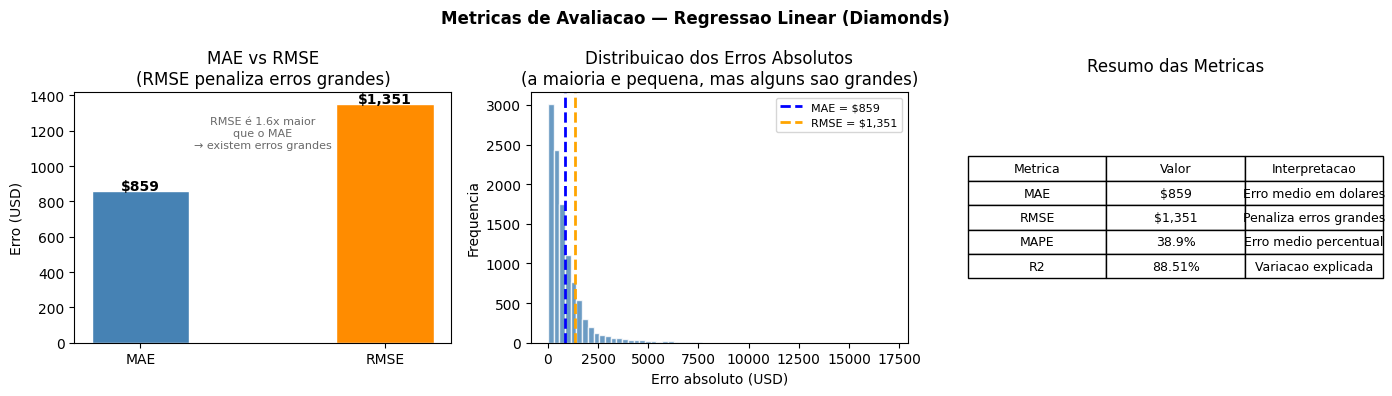

In [30]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_teste))
mape = np.mean(np.abs((y_test - y_pred_teste) / y_test)) * 100

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# --- Gráfico 1: Comparação MAE vs RMSE ---
ax1 = axes[0]
ax1.bar(['MAE', 'RMSE'], [mae_teste, rmse], color=['steelblue', 'darkorange'], edgecolor='white', width=0.4)
ax1.set_title('MAE vs RMSE\n(RMSE penaliza erros grandes)')
ax1.set_ylabel('Erro (USD)')
for i, v in enumerate([mae_teste, rmse]):
    ax1.text(i, v + 5, f'${v:,.0f}', ha='center', fontweight='bold')
ax1.annotate(f'RMSE é {rmse/mae_teste:.1f}x maior\nque o MAE\n→ existem erros grandes',
             xy=(0.5, (mae_teste + rmse)/2), ha='center', fontsize=8, color='dimgray',
             xycoords='data')

# --- Gráfico 2: Distribuição dos erros absolutos ---
ax2 = axes[1]
erros_abs = np.abs(y_test.values - y_pred_teste)
ax2.hist(erros_abs, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(mae_teste, color='blue',   linestyle='--', linewidth=2, label=f'MAE = ${mae_teste:,.0f}')
ax2.axvline(rmse,      color='orange', linestyle='--', linewidth=2, label=f'RMSE = ${rmse:,.0f}')
ax2.set_xlabel('Erro absoluto (USD)')
ax2.set_ylabel('Frequencia')
ax2.set_title('Distribuicao dos Erros Absolutos\n(a maioria e pequena, mas alguns sao grandes)')
ax2.legend(fontsize=8)

# --- Gráfico 3: Tabela resumo ---
ax3 = axes[2]
ax3.axis('off')
dados_tabela = [
    ['MAE',  f'${mae_teste:,.0f}', 'Erro medio em dolares'],
    ['RMSE', f'${rmse:,.0f}', 'Penaliza erros grandes'],
    ['MAPE', f'{mape:.1f}%',       'Erro medio percentual'],
    ['R2',   f'{r2_teste:.2%}',    'Variacao explicada'],
]
t = ax3.table(cellText=dados_tabela,
              colLabels=['Metrica', 'Valor', 'Interpretacao'],
              loc='center', cellLoc='center')
t.auto_set_font_size(False)
t.set_fontsize(9)
t.scale(1.1, 1.8)
ax3.set_title('Resumo das Metricas', pad=15)

plt.suptitle('Metricas de Avaliacao — Regressao Linear (Diamonds)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

# PARTE 7 — Matriz de Confusão

## 7.1. Por que precisamos disso se estamos fazendo regressão?

Até aqui trabalhamos com **regressão** — prever um número (preço).

Mas muitos problemas do mundo real são de **classificação** — prever uma categoria:
- Email: spam ou não spam?
- Transação: fraude ou legítima?
- Exame médico: positivo ou negativo?
- Cliente: vai cancelar o plano ou não?

Para problemas de classificação, as métricas de erro (MAE, RMSE) não fazem sentido — você não calcula a raiz quadrada de "spam" menos "não spam".

Precisamos de outras ferramentas. A principal é a **Matriz de Confusão**.

## 7.2. O que é a Matriz de Confusão

A Matriz de Confusão organiza os acertos e erros do modelo em uma tabela, separando **quais tipos de erro** aconteceram.

Vamos usar um exemplo concreto: **detectar diamantes caros** (acima de $5.000).

O modelo classifica cada diamante como "caro" ou "barato". Existem 4 resultados possíveis:

```
                        REALIDADE
                   Caro      |    Barato
              ┌─────────────────────────────┐
    PREVISTO  │  Verdadeiro  │   Falso      │
    Caro      │  Positivo    │   Positivo   │  ← Previu CARO
              │    (VP)      │     (FP)     │
              ├─────────────────────────────┤
    PREVISTO  │  Falso       │  Verdadeiro  │
    Barato    │  Negativo    │  Negativo    │  ← Previu BARATO
              │    (FN)      │    (VN)      │
              └─────────────────────────────┘
```

**Traduzindo:**
- **VP (Verdadeiro Positivo):** previu caro, era caro. ✅ Acertou!
- **VN (Verdadeiro Negativo):** previu barato, era barato. ✅ Acertou!
- **FP (Falso Positivo):** previu caro, mas era barato. ❌ Alarme falso.
- **FN (Falso Negativo):** previu barato, mas era caro. ❌ Deixou escapar.

## 7.3. Por que separar FP e FN importa tanto?

**Depende do problema, os erros têm custos diferentes!**

| Contexto | Falso Positivo (FP) | Falso Negativo (FN) | Qual é pior? |
|---|---|---|---|
| Detecção de câncer | Diagnóstico positivo falso → exame desnecessário | Não detectar câncer real → paciente morre sem tratamento | FN é catastrófico |
| Filtro de spam | Email legítimo vai para spam → frustração | Spam passa → inconveniente | FP é mais grave |
| Detecção de fraude | Transação legítima bloqueada → cliente irritado | Fraude não detectada → prejuízo financeiro | Depende do custo |

A acurácia sozinha não captura essa diferença. A Matriz de Confusão sim.

Matriz de Confusao:

  VN (acertou barato):    7,596
  VP (acertou caro):      2,567
  FP (disse caro, era barato):   315  <- Alarme falso
  FN (disse barato, era caro):   310  <- Deixou escapar


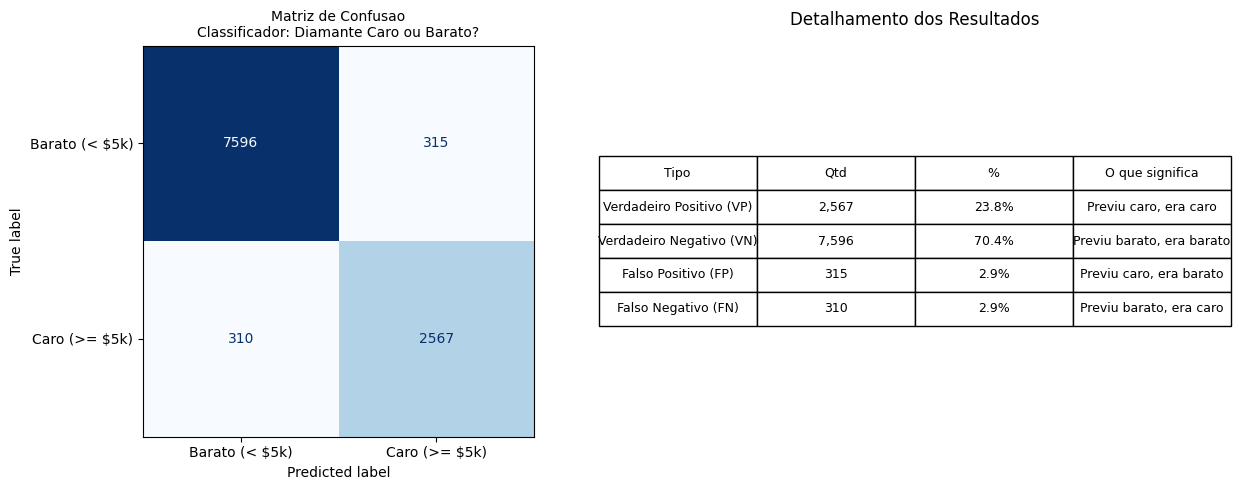

In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Criando problema de classificacao: diamante caro (>= 5000) ou barato?
y_class_train = (y_train >= 5000).astype(int)  # 1 = caro, 0 = barato
y_class_test  = (y_test  >= 5000).astype(int)

# Treinando classificador
clf = LogisticRegression(max_iter=1000, random_state=42)
clf.fit(X_train_sc, y_class_train)
y_class_pred = clf.predict(X_test_sc)

# Calculando a Matriz de Confusao
cm = confusion_matrix(y_class_test, y_class_pred)
vn, fp, fn, vp = cm.ravel()

print("Matriz de Confusao:")
print(f"\n  VN (acertou barato):    {vn:>5,}")
print(f"  VP (acertou caro):      {vp:>5,}")
print(f"  FP (disse caro, era barato): {fp:>5,}  <- Alarme falso")
print(f"  FN (disse barato, era caro): {fn:>5,}  <- Deixou escapar")

# Plotando
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Matriz de confusao visual
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Barato (< $5k)', 'Caro (>= $5k)'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusao\nClassificador: Diamante Caro ou Barato?', fontsize=10)

# Proporcoes
total = vn + vp + fp + fn
axes[1].axis('off')
dados = [
    ['Verdadeiro Positivo (VP)', f'{vp:,}', f'{vp/total:.1%}', 'Previu caro, era caro'],
    ['Verdadeiro Negativo (VN)', f'{vn:,}', f'{vn/total:.1%}', 'Previu barato, era barato'],
    ['Falso Positivo (FP)',      f'{fp:,}', f'{fp/total:.1%}', 'Previu caro, era barato'],
    ['Falso Negativo (FN)',      f'{fn:,}', f'{fn/total:.1%}', 'Previu barato, era caro'],
]
t = axes[1].table(cellText=dados,
                   colLabels=['Tipo', 'Qtd', '%', 'O que significa'],
                   loc='center', cellLoc='center')
t.auto_set_font_size(False)
t.set_fontsize(9)
t.scale(1.1, 2.0)
axes[1].set_title('Detalhamento dos Resultados', pad=15)

plt.tight_layout()
plt.show()

## 7.4. Métricas derivadas da Matriz de Confusão

A partir dos 4 valores da matriz, calculamos métricas mais específicas:

---

### Acurácia
**O que é:** proporção de previsões corretas sobre o total.

```
Acurácia = (VP + VN) / (VP + VN + FP + FN)
```

**Limitação crítica:** pode ser enganosa em classes desbalanceadas. Lembra do médico da introdução? 95% de acurácia dizendo "saudável" para todo mundo.

---

### Precisão (Precision)
**O que é:** dos que o modelo disse "positivo", quantos eram realmente positivos?

```
Precisão = VP / (VP + FP)
```

**Em palavras:** *"quando o modelo afirma que é caro, com qual frequência ele está certo?"*

**Quando importa:** quando um Falso Positivo é caro. Ex: bloquear uma transação legítima como fraude → cliente irritado.

---

### Recall (Sensibilidade)
**O que é:** dos que eram realmente positivos, quantos o modelo encontrou?

```
Recall = VP / (VP + FN)
```

**Em palavras:** *"de todos os diamantes caros, quantos o modelo identificou corretamente?"*

**Quando importa:** quando um Falso Negativo é caro. Ex: não detectar um câncer real → tragédia.

---

### F1-Score
**O que é:** a média harmônica entre Precisão e Recall — um número único que equilibra os dois.

```
F1 = 2 × (Precisão × Recall) / (Precisão + Recall)
```

**Quando usar:** quando você quer uma métrica única e as duas classes importam igualmente.

> **A tensão Precisão vs Recall:** existe um trade-off natural. Se você aumenta o limiar para dizer "positivo" (exige mais certeza), a Precisão sobe (erra menos alarmes falsos) mas o Recall cai (deixa escapar mais casos reais). É impossível maximizar os dois ao mesmo tempo — você precisa decidir qual erro é mais aceitável no seu contexto.

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

acuracia  = accuracy_score(y_class_test,  y_class_pred)
precisao  = precision_score(y_class_test, y_class_pred)
recall    = recall_score(y_class_test,    y_class_pred)
f1        = f1_score(y_class_test,        y_class_pred)

print("=" * 55)
print(f"{'Metrica':<20} {'Valor':>8}   {'Interpretacao'}")
print("-" * 55)
print(f"{'Acuracia':<20} {acuracia:>8.2%}   Acertos / Total")
print(f"{'Precisao':<20} {precisao:>8.2%}   Dos que previu como caro, quantos eram caro")
print(f"{'Recall':<20} {recall:>8.2%}   Dos caros reais, quantos o modelo encontrou")
print(f"{'F1-Score':<20} {f1:>8.2%}   Equilibrio Precisao vs Recall")
print("=" * 55)

# Relatório completo do sklearn
print("\nRelatorio completo:")
print(classification_report(y_class_test, y_class_pred,
                              target_names=['Barato (<$5k)', 'Caro (>=$5k)']))

Metrica                 Valor   Interpretacao
-------------------------------------------------------
Acuracia               94.21%   Acertos / Total
Precisao               89.07%   Dos que previu como caro, quantos eram caro
Recall                 89.22%   Dos caros reais, quantos o modelo encontrou
F1-Score               89.15%   Equilibrio Precisao vs Recall

Relatorio completo:
               precision    recall  f1-score   support

Barato (<$5k)       0.96      0.96      0.96      7911
 Caro (>=$5k)       0.89      0.89      0.89      2877

     accuracy                           0.94     10788
    macro avg       0.93      0.93      0.93     10788
 weighted avg       0.94      0.94      0.94     10788



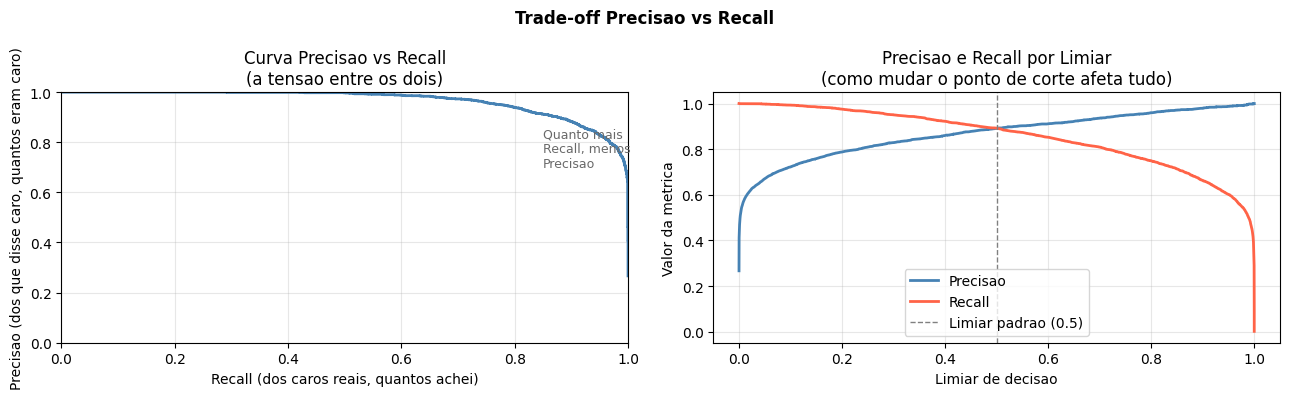

In [33]:
# Visualizando o trade-off Precisão vs Recall
from sklearn.metrics import precision_recall_curve

y_proba = clf.predict_proba(X_test_sc)[:, 1]  # probabilidade de ser caro
precisoes, recalls, limiares = precision_recall_curve(y_class_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Curva Precisao vs Recall
ax1 = axes[0]
ax1.plot(recalls, precisoes, color='steelblue', linewidth=2)
ax1.set_xlabel('Recall (dos caros reais, quantos achei)')
ax1.set_ylabel('Precisao (dos que disse caro, quantos eram caro)')
ax1.set_title('Curva Precisao vs Recall\n(a tensao entre os dois)')
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])
ax1.grid(alpha=0.3)
ax1.annotate('Quanto mais\nRecall, menos\nPrecisao', xy=(0.85, 0.70),
             fontsize=9, color='dimgray')

# Precisão e Recall por limiar
ax2 = axes[1]
ax2.plot(limiares, precisoes[:-1], color='steelblue', linewidth=2, label='Precisao')
ax2.plot(limiares, recalls[:-1],   color='tomato',    linewidth=2, label='Recall')
ax2.axvline(0.5, color='gray', linestyle='--', linewidth=1, label='Limiar padrao (0.5)')
ax2.set_xlabel('Limiar de decisao')
ax2.set_ylabel('Valor da metrica')
ax2.set_title('Precisao e Recall por Limiar\n(como mudar o ponto de corte afeta tudo)')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Trade-off Precisao vs Recall', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---

# PARTE 8 — Resíduos: o modelo erra de forma aleatória?

## 8.1. O que é um resíduo e por que analisar

**Resíduo = Valor Real − Valor Previsto**

É o erro individual de cada previsão. Se o diamante custava $5.000 e o modelo previu $4.300, o resíduo é $700.

**Por que olhar para os resíduos individualmente, se já temos o MAE?**

O MAE te diz *quanto* o modelo erra em média. Os resíduos te dizem *como* o modelo erra — e isso revela se existe algum **padrão nos erros**.

**Um modelo bom erra de forma aleatória.** Se os erros têm padrão, significa que o modelo deixou de capturar algo importante.

**Analogia do arqueiro:** um arqueiro treinado errou o alvo 10 vezes. Se as flechas ficaram espalhadas aleatoriamente em volta do centro, ele está treinando bem — o erro é ruído natural. Mas se todas as flechas foram para a esquerda, ele tem um problema sistemático: talvez a mira esteja descalibrada, talvez o vento, talvez ele esteja doente. Esse padrão precisa ser corrigido.

**O que procurar nos gráficos de resíduo:**

| O que você vê | O que significa |
|---|---|
| Nuvem aleatória de pontos ao redor do zero | ✅ Modelo saudável, erros são ruído |
| Resíduos crescem conforme o valor previsto cresce | ⚠️ Heterocedasticidade — erro não é constante |
| Distribuição assimétrica (mais erros para um lado) | ⚠️ Viés sistemático — modelo superestima ou subestima |
| Formato de curva nos resíduos vs previsto | ⚠️ Relação não-linear não capturada |

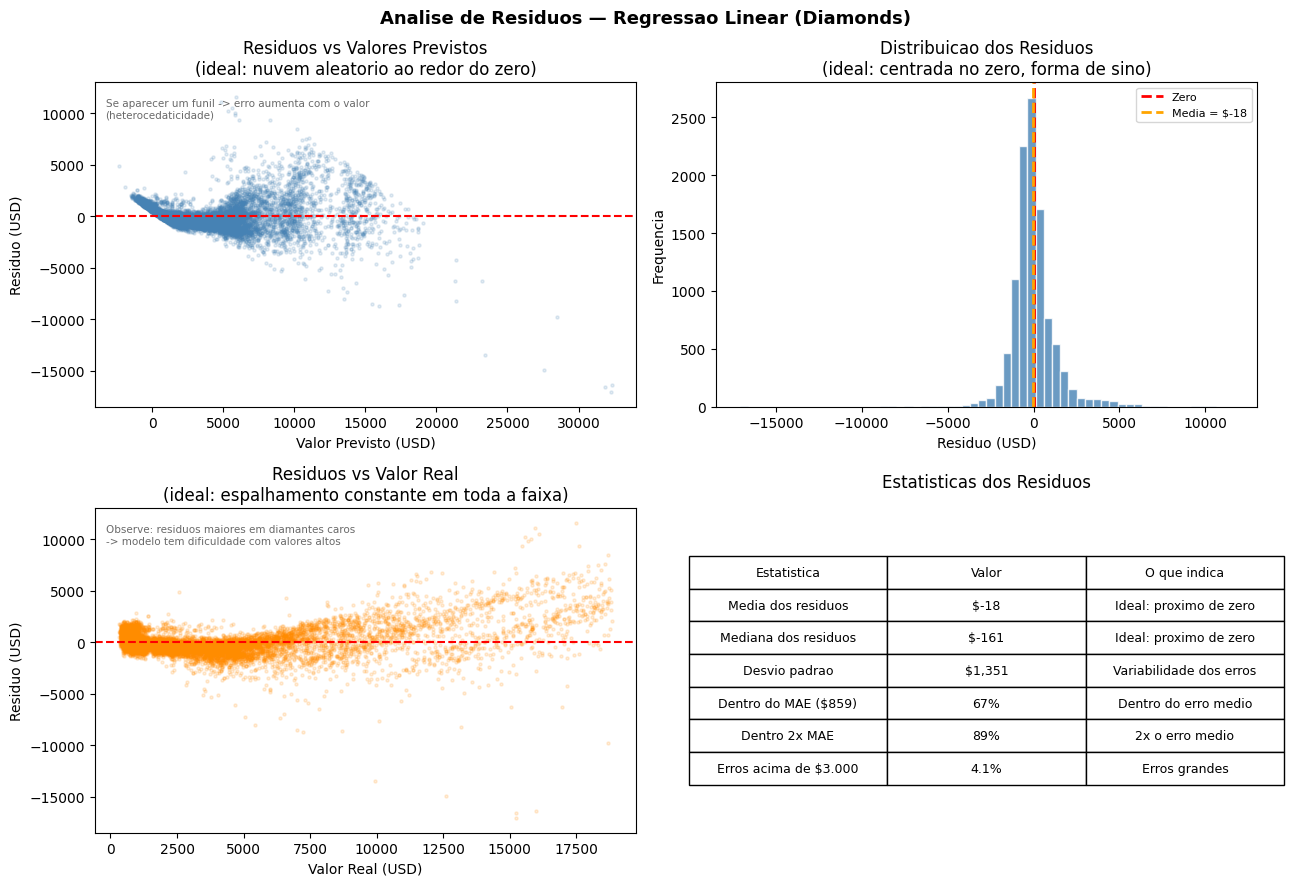

In [34]:
residuos = y_test.values - y_pred_teste

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# --- Gráfico 1: Residuos vs Valores Previstos ---
ax1 = axes[0, 0]
ax1.scatter(y_pred_teste, residuos, alpha=0.15, color='steelblue', s=5)
ax1.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Valor Previsto (USD)')
ax1.set_ylabel('Residuo (USD)')
ax1.set_title('Residuos vs Valores Previstos\n(ideal: nuvem aleatorio ao redor do zero)')
ax1.text(0.02, 0.95, 'Se aparecer um funil -> erro aumenta com o valor\n(heterocedaticidade)',
         transform=ax1.transAxes, fontsize=7.5, color='dimgray', va='top')

# --- Gráfico 2: Distribuição dos resíduos ---
ax2 = axes[0, 1]
ax2.hist(residuos, bins=60, color='steelblue', edgecolor='white', alpha=0.8)
ax2.axvline(0,               color='red',    linestyle='--', linewidth=2, label='Zero')
ax2.axvline(residuos.mean(), color='orange', linestyle='--', linewidth=2,
            label=f'Media = ${residuos.mean():,.0f}')
ax2.set_xlabel('Residuo (USD)')
ax2.set_ylabel('Frequencia')
ax2.set_title('Distribuicao dos Residuos\n(ideal: centrada no zero, forma de sino)')
ax2.legend(fontsize=8)

# --- Gráfico 3: Residuos vs Valor Real ---
ax3 = axes[1, 0]
ax3.scatter(y_test, residuos, alpha=0.15, color='darkorange', s=5)
ax3.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax3.set_xlabel('Valor Real (USD)')
ax3.set_ylabel('Residuo (USD)')
ax3.set_title('Residuos vs Valor Real\n(ideal: espalhamento constante em toda a faixa)')
ax3.text(0.02, 0.95, 'Observe: residuos maiores em diamantes caros\n-> modelo tem dificuldade com valores altos',
         transform=ax3.transAxes, fontsize=7.5, color='dimgray', va='top')

# --- Gráfico 4: Estatísticas dos resíduos ---
ax4 = axes[1, 1]
ax4.axis('off')
pct_dentro_mae    = np.mean(np.abs(residuos) <= mae_teste) * 100
pct_dentro_2mae   = np.mean(np.abs(residuos) <= 2*mae_teste) * 100
pct_erro_grande   = np.mean(np.abs(residuos) > 3000) * 100
dados_res = [
    ['Media dos residuos',         f'${residuos.mean():,.0f}',  'Ideal: proximo de zero'],
    ['Mediana dos residuos',       f'${np.median(residuos):,.0f}', 'Ideal: proximo de zero'],
    ['Desvio padrao',              f'${residuos.std():,.0f}',   'Variabilidade dos erros'],
    [f'Dentro do MAE (${mae_teste:,.0f})', f'{pct_dentro_mae:.0f}%', 'Dentro do erro medio'],
    [f'Dentro 2x MAE',             f'{pct_dentro_2mae:.0f}%',  '2x o erro medio'],
    ['Erros acima de $3.000',      f'{pct_erro_grande:.1f}%',  'Erros grandes'],
]
t = ax4.table(cellText=dados_res,
              colLabels=['Estatistica', 'Valor', 'O que indica'],
              loc='center', cellLoc='center')
t.auto_set_font_size(False)
t.set_fontsize(9)
t.scale(1.1, 1.9)
ax4.set_title('Estatisticas dos Residuos', pad=15)

plt.suptitle('Analise de Residuos — Regressao Linear (Diamonds)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Conclusão da análise de resíduos:**

O modelo tem um problema claro: para diamantes caros (acima de ~$10.000), os resíduos ficam muito maiores e mais espalhados. Isso indica que a relação entre as variáveis e o preço **não é perfeitamente linear** para valores altos.

Isso não torna o modelo inútil — mas nos diz que para previsões de diamantes premium, precisaríamos de um modelo mais sofisticado.

---

# PARTE 9 — Teste de Hipótese e P-value

## 9.1. O problema que o teste de hipótese resolve

Você olha para os dados e percebe que diamantes com corte "Ideal" custam em média $200 mais que diamantes com corte "Premium".

Isso é real? Ou é só variação aleatória nos dados que você coletou?

Se você tivesse coletado outros 54.000 diamantes diferentes, essa diferença de $200 ainda apareceria? Ou sumia?

**O Teste de Hipótese é o método formal para responder essa pergunta.**

## 9.2. A lógica do Teste de Hipótese

O raciocínio funciona assim:

1. **Você parte do princípio que nada especial está acontecendo** — que a diferença que você observou é puro acaso. Isso se chama **Hipótese Nula (H₀)**.

2. **Você calcula: se a hipótese nula fosse verdadeira, qual a probabilidade de observar o que observei?** Essa probabilidade é o **p-value**.

3. **Se o p-value for muito baixo** (convencionalmente < 5%), significa que os dados que você viu são muito improváveis de acontecer por acaso. Logo, a hipótese nula provavelmente está errada — há algo real acontecendo.

## 9.3. A Hipótese Nula

A **Hipótese Nula (H₀)** é sempre a afirmação de que *não existe efeito*, *não existe diferença*, *não existe relação*.

Exemplos:
- "O tipo de corte **não** afeta o preço do diamante" → H₀
- "O coeficiente do quilate no modelo é **zero**" → H₀
- "O novo remédio **não** é melhor que o placebo" → H₀

A **Hipótese Alternativa (H₁)** é o oposto — que sim, existe efeito.

Você nunca prova que H₁ é verdadeira. Você apenas coleta evidências contra H₀. Se a evidência é forte o suficiente, você **rejeita a hipótese nula**.

## 9.4. O P-value em detalhe

**Definição formal:** o p-value é a probabilidade de observar um resultado **tão extremo quanto o observado**, assumindo que a hipótese nula é verdadeira.

**Em palavras simples:** *"se não houvesse efeito real, qual a chance de os dados terem ficado assim por coincidência?"*

**A analogia da moeda:**

Você suspeita que uma moeda é viciada. Joga 10 vezes e cai cara 8 vezes.

- Hipótese Nula: *"a moeda é honesta"*
- Pergunta: *"se a moeda fosse honesta, qual a chance de cair cara 8 ou mais vezes em 10 lançamentos?"*
- Resposta: ~5.5% → p-value ≈ 0.055

Isso é ligeiramente acima de 5% — evidência fraca contra a moeda honesta.

Agora jogue 100 vezes e caia cara 70. O p-value seria minúsculo → evidência fortíssima de que a moeda é viciada.

**O limiar de 5% (p < 0.05):**

É uma convenção histórica da ciência. Significa: *"só vou concluir que existe um efeito real se a chance de ser coincidência for menor que 5%"*.

Não é um número mágico — em medicina usa-se 1%, em física usa-se 0.0001%. Depende do contexto e do custo de errar.

**O que p-value NÃO é:**
- Não é a probabilidade de H₀ ser verdadeira
- Não mede o tamanho do efeito (algo pode ser significante estatisticamente mas irrelevante na prática)
- Um p-value alto não prova que H₀ é verdadeira — só que não temos evidência suficiente contra ela

## 9.5. Aplicando na Regressão: p-value dos coeficientes

Na regressão linear, cada variável tem um coeficiente. O p-value de cada coeficiente responde:

> *"Se esse coeficiente fosse zero na realidade (variável não tem efeito), qual a chance de observarmos um coeficiente tão grande quanto o que calculamos?"*

- p < 0.05 → evidência de que essa variável tem efeito real no preço ✅
- p ≥ 0.05 → não temos evidência suficiente — pode ser coincidência ❌

In [35]:
import statsmodels.api as sm

# statsmodels exige adicionar a constante (intercepto) manualmente
X_train_sm = sm.add_constant(X_train_sc)
X_test_sm  = sm.add_constant(X_test_sc)

# Ajustando o modelo de regressão com estatísticas completas
modelo_sm = sm.OLS(y_train, X_train_sm).fit()

print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                 3.691e+04
Date:                Thu, 23 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:04:54   Log-Likelihood:            -3.7235e+05
No. Observations:               43152   AIC:                         7.447e+05
Df Residuals:                   43142   BIC:                         7.448e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       3939.4907      6.513    604.862      0.0

In [36]:
# Extraindo de forma legível
nomes_features = ['intercepto'] + list(X.columns)

resumo = pd.DataFrame({
    'Feature':     nomes_features,
    'Coeficiente': modelo_sm.params.values.round(1),
    'P-value':     modelo_sm.pvalues.values,
    'IC_inf':      modelo_sm.conf_int().iloc[:, 0].values.round(1),
    'IC_sup':      modelo_sm.conf_int().iloc[:, 1].values.round(1),
})

resumo['Significante'] = resumo['P-value'].apply(
    lambda p: 'Sim (p<0.05)' if p < 0.05 else 'NAO'
)
resumo['P-value_fmt'] = resumo['P-value'].apply(
    lambda p: f'{p:.4f}' if p >= 0.0001 else '<0.0001'
)

print(f"{'Feature':<15} {'Coef':>10} {'P-value':>10} {'Significante':>15} {'Intervalo 95%'}")
print("-" * 70)
for _, row in resumo.iterrows():
    print(f"{row['Feature']:<15} {row['Coeficiente']:>10.1f} {row['P-value_fmt']:>10} "
          f"{row['Significante']:>15}  [{row['IC_inf']:.1f}, {row['IC_sup']:.1f}]")

Feature               Coef    P-value    Significante Intervalo 95%
----------------------------------------------------------------------
intercepto          3939.5    <0.0001    Sim (p<0.05)  [3926.7, 3952.3]
carat               5203.3    <0.0001    Sim (p<0.05)  [5143.7, 5262.9]
cut                   73.9    <0.0001    Sim (p<0.05)  [60.8, 87.0]
color               -456.4    <0.0001    Sim (p<0.05)  [-469.8, -443.1]
clarity              493.8    <0.0001    Sim (p<0.05)  [480.7, 507.0]
depth               -222.4    <0.0001    Sim (p<0.05)  [-237.9, -206.8]
table               -210.4    <0.0001    Sim (p<0.05)  [-224.2, -196.7]
x                  -1310.9    <0.0001    Sim (p<0.05)  [-1400.9, -1220.8]
y                     27.3     0.3043             NAO  [-24.8, 79.4]
z                      8.6     0.7629             NAO  [-47.4, 64.6]


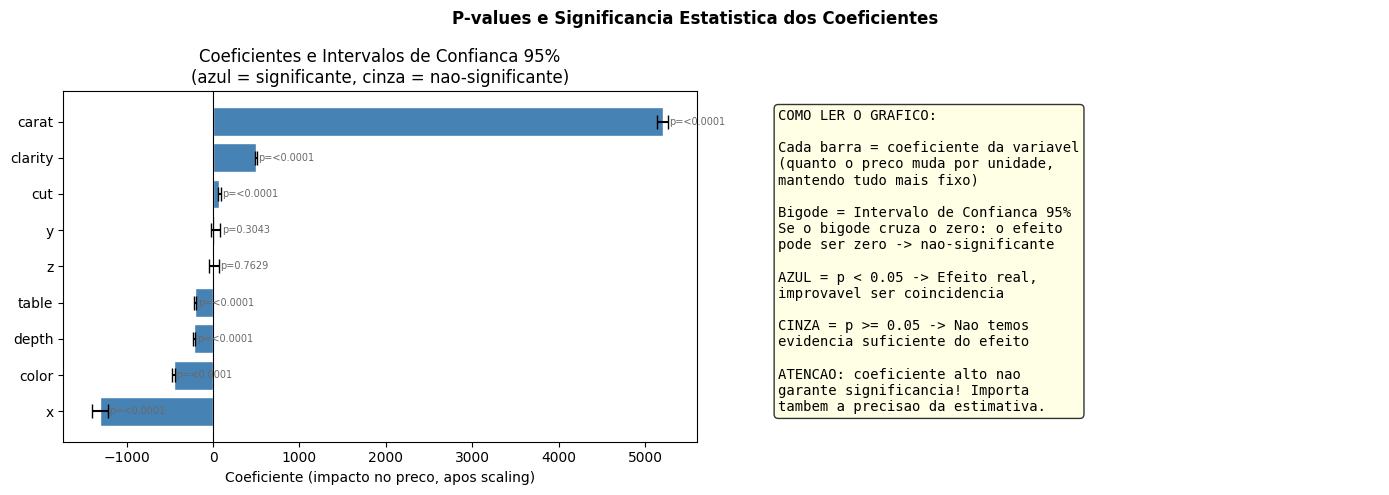

In [37]:
# Visualização dos coeficientes com intervalo de confiança
df_plot = resumo[resumo['Feature'] != 'intercepto'].copy().sort_values('Coeficiente')

cores_sig = ['steelblue' if p < 0.05 else 'lightgray' for p in df_plot['P-value']]
erros = [(r['Coeficiente'] - r['IC_inf'], r['IC_sup'] - r['Coeficiente'])
          for _, r in df_plot.iterrows()]
erros_neg, erros_pos = zip(*erros)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Coeficientes com IC
ax1 = axes[0]
bars = ax1.barh(df_plot['Feature'], df_plot['Coeficiente'],
                 xerr=[erros_neg, erros_pos],
                 color=cores_sig, edgecolor='white', capsize=5,
                 error_kw={'linewidth': 1.5, 'color': 'gray'})
ax1.axvline(0, color='black', linewidth=0.8)
ax1.set_xlabel('Coeficiente (impacto no preco, apos scaling)')
ax1.set_title('Coeficientes e Intervalos de Confianca 95%\n(azul = significante, cinza = nao-significante)')

# Anotando p-values
for i, (_, row) in enumerate(df_plot.iterrows()):
    label = row['P-value_fmt']
    x = row['IC_sup'] + 20
    ax1.text(x, i, f'p={label}', va='center', fontsize=7, color='dimgray')

# Gráfico 2: Explicação do Intervalo de Confiança
ax2 = axes[1]
ax2.axis('off')
texto = (
    "COMO LER O GRAFICO:\n\n"
    "Cada barra = coeficiente da variavel\n"
    "(quanto o preco muda por unidade,\n"
    "mantendo tudo mais fixo)\n\n"
    "Bigode = Intervalo de Confianca 95%\n"
    "Se o bigode cruza o zero: o efeito\n"
    "pode ser zero -> nao-significante\n\n"
    "AZUL = p < 0.05 -> Efeito real,\n"
    "improvavel ser coincidencia\n\n"
    "CINZA = p >= 0.05 -> Nao temos\n"
    "evidencia suficiente do efeito\n\n"
    "ATENCAO: coeficiente alto nao\n"
    "garante significancia! Importa\n"
    "tambem a precisao da estimativa."
)
ax2.text(0.05, 0.95, texto, transform=ax2.transAxes,
          fontsize=10, va='top', family='monospace',
          bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))

plt.suptitle('P-values e Significancia Estatistica dos Coeficientes', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 9.6. Correlação vs Significância — a diferença que muda tudo

Essa é uma das confusões mais comuns em Ciência de Dados:

**Correlação** pergunta: *"X e Y estão associados nos dados?"*

**Significância** pergunta: *"Essa associação é real ou pode ser coincidência?"*

São perguntas diferentes, e os resultados podem divergir:

| Situação | Correlação | Significância | O que fazer |
|---|---|---|---|
| Alta correlação, p < 0.05 | Alta | Sim | Manter a variável ✅ |
| Alta correlação, p ≥ 0.05 | Alta | Não | Investigar — dados insuficientes? |
| Baixa correlação, p < 0.05 | Baixa | Sim | Efeito real mas pequeno — depende do contexto |
| Baixa correlação, p ≥ 0.05 | Baixa | Não | Remover a variável |

Com 54.000 diamantes, quase tudo vai ser significante estatisticamente (grande volume de dados reduz o p-value). **Nesse caso, o tamanho do coeficiente importa mais do que a significância.**

> **Regra de ouro:** em datasets grandes, p-value baixo é quase garantido. O que importa é o **tamanho do efeito** — o coeficiente é grande o suficiente para ser relevante na prática?

---

# PARTE 10 — Dashboard Final de Avaliação

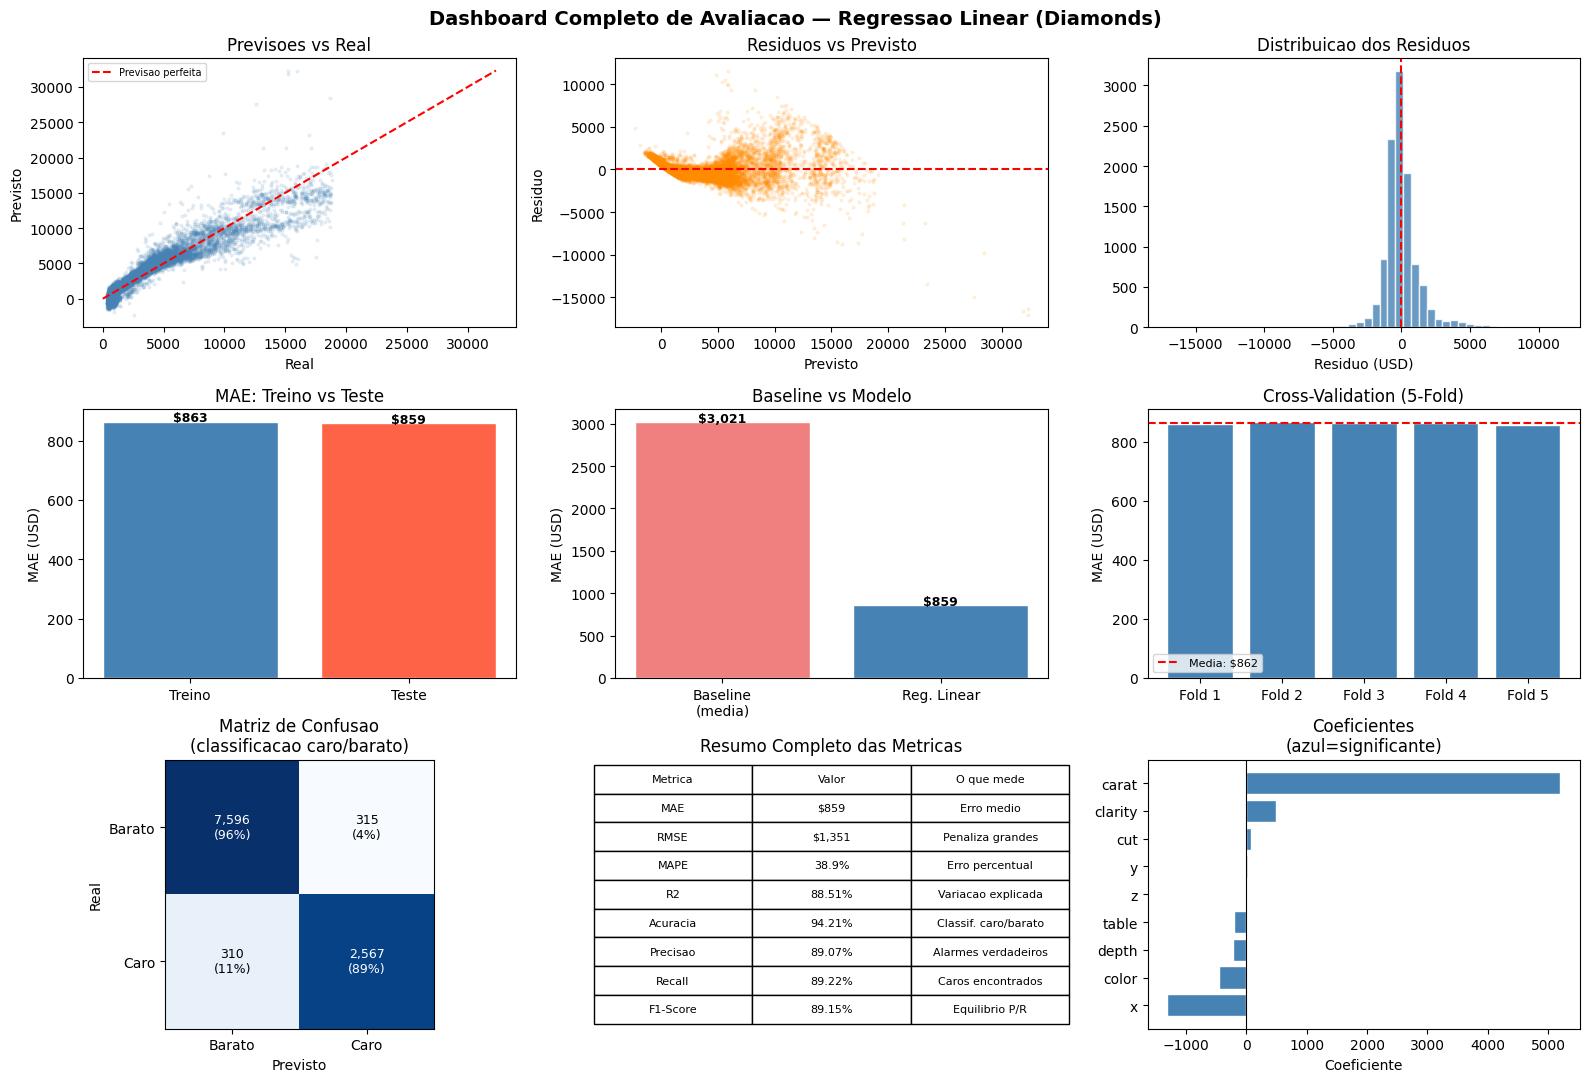

In [38]:
fig = plt.figure(figsize=(16, 11))
fig.suptitle('Dashboard Completo de Avaliacao — Regressao Linear (Diamonds)',
             fontsize=14, fontweight='bold')

# 1. Previsoes vs Real
ax1 = fig.add_subplot(3, 3, 1)
ax1.scatter(y_test, y_pred_teste, alpha=0.1, color='steelblue', s=4)
lim = max(y_test.max(), y_pred_teste.max())
ax1.plot([0, lim], [0, lim], 'r--', linewidth=1.5, label='Previsao perfeita')
ax1.set_xlabel('Real'); ax1.set_ylabel('Previsto')
ax1.set_title('Previsoes vs Real')
ax1.legend(fontsize=7)

# 2. Residuos vs Previsto
ax2 = fig.add_subplot(3, 3, 2)
ax2.scatter(y_pred_teste, residuos, alpha=0.1, color='darkorange', s=4)
ax2.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel('Previsto'); ax2.set_ylabel('Residuo')
ax2.set_title('Residuos vs Previsto')

# 3. Distribuicao residuos
ax3 = fig.add_subplot(3, 3, 3)
ax3.hist(residuos, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
ax3.axvline(0, color='red', linestyle='--')
ax3.set_xlabel('Residuo (USD)'); ax3.set_title('Distribuicao dos Residuos')

# 4. Treino vs Teste
ax4 = fig.add_subplot(3, 3, 4)
ax4.bar(['Treino', 'Teste'], [mae_treino, mae_teste],
         color=['steelblue', 'tomato'], edgecolor='white')
for i, v in enumerate([mae_treino, mae_teste]):
    ax4.text(i, v + 2, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)
ax4.set_title('MAE: Treino vs Teste')
ax4.set_ylabel('MAE (USD)')

# 5. Baseline
ax5 = fig.add_subplot(3, 3, 5)
ax5.bar(['Baseline\n(media)', 'Reg. Linear'],
         [mae_bl_media, mae_teste],
         color=['lightcoral', 'steelblue'], edgecolor='white')
for i, v in enumerate([mae_bl_media, mae_teste]):
    ax5.text(i, v + 2, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)
ax5.set_title('Baseline vs Modelo')
ax5.set_ylabel('MAE (USD)')

# 6. Cross-Validation
ax6 = fig.add_subplot(3, 3, 6)
ax6.bar([f'Fold {i+1}' for i in range(5)], scores_5,
         color='steelblue', edgecolor='white')
ax6.axhline(scores_5.mean(), color='red', linestyle='--', linewidth=1.5,
             label=f'Media: ${scores_5.mean():,.0f}')
ax6.set_title('Cross-Validation (5-Fold)')
ax6.set_ylabel('MAE (USD)')
ax6.legend(fontsize=8)

# 7. Matriz de confusao
ax7 = fig.add_subplot(3, 3, 7)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
im = ax7.imshow(cm_norm, interpolation='nearest', cmap='Blues')
ax7.set_xticks([0, 1]); ax7.set_yticks([0, 1])
ax7.set_xticklabels(['Barato', 'Caro'])
ax7.set_yticklabels(['Barato', 'Caro'])
for i in range(2):
    for j in range(2):
        ax7.text(j, i, f'{cm[i,j]:,}\n({cm_norm[i,j]:.0%})',
                  ha='center', va='center', fontsize=9,
                  color='white' if cm_norm[i,j] > 0.5 else 'black')
ax7.set_xlabel('Previsto'); ax7.set_ylabel('Real')
ax7.set_title('Matriz de Confusao\n(classificacao caro/barato)')

# 8. Metricas resumo
ax8 = fig.add_subplot(3, 3, 8)
ax8.axis('off')
tabela_final = [
    ['MAE',       f'${mae_teste:,.0f}', 'Erro medio'],
    ['RMSE',      f'${rmse:,.0f}',      'Penaliza grandes'],
    ['MAPE',      f'{mape:.1f}%',        'Erro percentual'],
    ['R2',        f'{r2_teste:.2%}',     'Variacao explicada'],
    ['Acuracia',  f'{acuracia:.2%}',     'Classif. caro/barato'],
    ['Precisao',  f'{precisao:.2%}',     'Alarmes verdadeiros'],
    ['Recall',    f'{recall:.2%}',       'Caros encontrados'],
    ['F1-Score',  f'{f1:.2%}',           'Equilibrio P/R'],
]
t = ax8.table(cellText=tabela_final,
               colLabels=['Metrica', 'Valor', 'O que mede'],
               loc='center', cellLoc='center')
t.auto_set_font_size(False)
t.set_fontsize(8)
t.scale(1.1, 1.6)
ax8.set_title('Resumo Completo das Metricas')

# 9. Coeficientes
ax9 = fig.add_subplot(3, 3, 9)
df_coef = resumo[resumo['Feature'] != 'intercepto'].sort_values('Coeficiente')
cores_c = ['steelblue' if p < 0.05 else 'lightgray' for p in df_coef['P-value']]
ax9.barh(df_coef['Feature'], df_coef['Coeficiente'], color=cores_c, edgecolor='white')
ax9.axvline(0, color='black', linewidth=0.8)
ax9.set_title('Coeficientes\n(azul=significante)')
ax9.set_xlabel('Coeficiente')

plt.tight_layout()
plt.show()

---

# Checklist de Avaliação — Leve para a vida

```
ANTES DE DECLARAR QUE SEU MODELO E BOM:

[ ] 1. Comparei com o BASELINE?
       O modelo e melhor do que chutar a media?

[ ] 2. Comparei TREINO vs TESTE?
       Erro parecido nos dois? Ou overfitting?

[ ] 3. Usei CROSS-VALIDATION?
       O resultado e estavel entre os folds?

[ ] 4. Analisei as METRICAS certas para o contexto?
       - Erros grandes sao graves? -> olha o RMSE
       - Precisa comunicar para nao-tecnicos? -> usa MAPE
       - Classificacao com classes desbalanceadas? -> nao usa so acuracia

[ ] 5. Olhei a MATRIZ DE CONFUSAO (se for classificacao)?
       Que tipo de erro e mais grave: FP ou FN?

[ ] 6. Analisei os RESIDUOS?
       Ha algum padrao nos erros?

[ ] 7. Verifiquei os P-VALUES?
       Quais variaveis tem efeito real?

[ ] 8. O modelo FAZ SENTIDO?
       Os coeficientes estao na direcao esperada?
       Ou alguma coisa absurda esta acontecendo?
```

---

# Exercícios

---

## 🟢 Fácil

**Exercício 1 — Diagnóstico treino vs teste**

Simule overfitting: treine o modelo com apenas **100 diamantes** e avalie no teste completo.
- Qual o MAE no treino? E no teste?
- A diferença é maior do que com o conjunto completo de treino?
- Por que isso acontece?

In [39]:
# Exercicio 1


**Exercício 2 — MAPE vs MAE**

Calcule o MAPE do baseline (media) e da regressao linear.
- A melhoria percentual é maior no MAE ou no MAPE?
- O que isso indica sobre onde o modelo melhora mais: em diamantes baratos ou caros?

In [40]:
# Exercicio 2


---

## 🟡 Médio

**Exercício 3 — Cross-validation e estabilidade**

Rode cross-validation com K=5 e K=10.
- O MAE médio muda entre os dois?
- O desvio padrão muda? Em qual direção?
- Com base nisso, existe razão para usar K=10 nesse dataset? Justifique.

In [41]:
# Exercicio 3


**Exercício 4 — Matriz de Confusão com limiar diferente**

No classificador de diamantes caros, o limiar padrão é 0.5 (se a probabilidade > 50%, classifica como caro).

Mude o limiar para **0.3** e depois para **0.7**:
- Como muda a Precisao e o Recall em cada caso?
- Se você fosse um comprador que quer ter certeza de nao pagar caro por algo barato, qual limiar preferiria? E se fosse um vendedor querendo nao deixar escapar nenhum diamante caro?

*Dica: use `clf.predict_proba(X_test_sc)[:, 1] > 0.3` para classificar com limiar 0.3*

In [42]:
# Exercicio 4


---

## 🔴 Difícil

**Exercício 5 — P-values e seleção de variáveis**

Usando o `modelo_sm` (statsmodels):

1. Identifique todas as variáveis com p-value >= 0.05.
2. Remova essas variáveis e retreine o modelo com statsmodels.
3. Compare R², MAE (no teste via sklearn), e os novos p-values.
4. Reflita: remover variáveis não-significantes sempre melhora o modelo? Por quê?

*Dica: lembre de remover a variável tanto de X_train_sc quanto de X_test_sc — use índices de coluna.*

In [43]:
# Exercicio 5


**Exercício 6 — Análise completa com transformação log**

Uma limitação do modelo é que os residuos crescem para diamantes caros. Uma solução clássica é aplicar log no alvo antes de treinar.

Faça o pipeline completo com `y_log = np.log(y)` como alvo:

1. Treine o modelo com y_log
2. Converta as previsoes de volta com `np.exp(y_pred_log)`
3. Calcule MAE, RMSE, MAPE e R² originais
4. Plote os residuos (usando os valores convertidos de volta)
5. Rode cross-validation
6. Compare tudo com o modelo sem log

Pergunta final: o modelo com log resolve o problema dos residuos crescentes? Por que faz sentido aplicar log no preco de diamantes?

In [44]:
# Exercicio 6


---

## Resumo Final

| Conceito | O que é | Para que serve |
|---|---|---|
| **Overfitting** | Modelo decorou os dados de treino | Diagnosticado comparando treino vs teste |
| **Underfitting** | Modelo simples demais | Ambos os erros sao altos |
| **Learning Curve** | Erro vs quantidade de dados | Ver se mais dados ajudam |
| **Cross-Validation** | Testar em todas as partes dos dados | Avaliacao robusta e confiavel |
| **Baseline** | Modelo idiota de referencia | Piso minimo de qualidade |
| **MAE** | Erro medio absoluto | Interpretacao direta |
| **RMSE** | Penaliza erros grandes | Quando grandes erros sao criticos |
| **MAPE** | Erro percentual | Comunicacao para nao-tecnicos |
| **Matriz de Confusao** | Organiza tipos de erros | Classificacao — entender FP e FN |
| **Precisao** | Dos que previ positivo, acertei? | Minimizar alarmes falsos |
| **Recall** | Dos positivos reais, achei? | Minimizar casos nao detectados |
| **F1-Score** | Equilibrio P e R | Quando as duas classes importam |
| **Residuos** | Padrao nos erros | Detectar problemas estruturais |
| **Hipotese Nula** | Assume que nao existe efeito | Base do teste de hipotese |
| **P-value** | Prob. do efeito ser coincidencia | p < 0.05 = efeito real |
| **statsmodels** | Regressao com estatisticas | Coeficientes + p-values + IC |

> **A frase que resume a aula:** *Um modelo nao e bom porque o R² e alto. E bom quando sobrevive a todas as perguntas desta tabela.*